In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# LRT Line and Stations — Stop-to-Stop Travel Times, Underground vs Ground-Level Scenarios

Geometry of the planned line **`Input/GeneralHalufa/hf_lrt_3.shp`** (one polyline, WGS 84) and its stations **`station_hf_lrt_3.geojson`** (46 platform points), turned into a station table with chainage, inter-station distances and TAZ / V2-area membership, and into **station-to-station in-vehicle travel-time matrices** under two scenarios: every station underground, every station at ground level.

**Travel-time function.** The calibrated transit in-vehicle time function of the *Transit In-Vehicle Travel Time Calibration Report* (OperatorRef 22 — the Tel Aviv Red Line; Thursdays May 2023 – September 2026; 26,653 clean complete journeys, 799,590 stop-to-stop sections):

`T_trip [min] = 1.960792 × N_UG + 2.392690 × N_Other`

i.e. **1.961 min per underground section and 2.393 min per other section**, dwell included; a section is underground only when both its end stations are. The report converts these to speeds under a *modelling assumption of 500 m between consecutive stops* (15.3 / 12.5 km/h) and itself warns that the assumption is not the physical spacing.

**The 500 m assumption checked (revision 2, 22 September 2026).** The Red Line's timetable is in the national GTFS (`Input/GTFS/israel-public-transportation.zip`, operator 22, routes 34447 / 34448), with the distance travelled at every stop. Its underground sections average **970 m** and its surface sections **577 m** — so the calibrated 1.961 min per underground section is a 30 km/h section, not a 15 km/h one, and the first revision of this notebook, which spread the per-section times over 500 m, made the underground scenario twice too slow. The function is therefore applied here in a **running-time + stop-penalty form**: on the Red Line's 14,477 scheduled sections the section time fits `t = a + b × km` per regime (underground: 0.81 min + 1.31 min/km, i.e. 46 km/h running and a 49-second stop penalty; surface: 1.23 min + 1.94 min/km, 31 km/h and 74 seconds), and each regime is levelled to the calibration's observed mean (underground 1.961 / scheduled 2.082 = 0.94; surface 2.393 / 2.347 = 1.02). This transfers the calibration to any station spacing. Two other readings are kept for the record: the **section form** (one calibrated section per link, whatever its length — the fast bound on Haifa's 815 m spacing) and the **nominal 500 m form** of revision 1 (the slow bound; superseded).

In [2]:
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapefile
from pyproj import Transformer
from shapely.geometry import LineString, Point, shape
from shapely.strtree import STRtree

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/lrt_v2'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
# ---- calibrated coefficients (report §6): observed mean minutes per section, by regime ----
COEF_SECTION = {'underground': 1.960792, 'ground': 2.392690}
COEF_KM_NOMINAL = {k: v / 0.5 for k, v in COEF_SECTION.items()}        # the report's 500 m reading (revision 1 of this notebook) — kept as the slow bound
SCEN = {'all_underground': 'underground', 'all_ground': 'ground'}
GTFS = 'Input/GTFS/israel-public-transportation.zip'
HAVE_GTFS = os.path.exists(GTFS) and not open(GTFS, 'rb').read(40).startswith(b'version https://git-lfs')

# ---- geometry: WGS 84 -> Israel TM Grid (EPSG:2039), the CRS of the TAZ shapefile ----
to_itm = Transformer.from_crs('EPSG:4326', 'EPSG:2039', always_xy=True); to_wgs = Transformer.from_crs('EPSG:2039', 'EPSG:4326', always_xy=True)
line_shp = shapefile.Reader('Input/GeneralHalufa/hf_lrt_3'); assert len(line_shp) == 1
L = LineString([to_itm.transform(x, y) for x, y in line_shp.shape(0).points]); LEN = L.length
gj = json.load(open('Input/GeneralHalufa/station_hf_lrt_3.geojson'))
pts = pd.DataFrame([{'point': i, 'halufa': f['properties']['halufa'], 'lon': f['geometry']['coordinates'][0], 'lat': f['geometry']['coordinates'][1]} for i, f in enumerate(gj['features'])])
pts[['x', 'y']] = [to_itm.transform(lo, la) for lo, la in zip(pts['lon'], pts['lat'])]
pts['chain_from_file_start'] = [L.project(Point(x, y)) for x, y in zip(pts['x'], pts['y'])]
pts['offset_m'] = [L.distance(Point(x, y)) for x, y in zip(pts['x'], pts['y'])]
# the polyline runs from Hamifrats (file start) to Tirat Carmel; chainage is measured from the Tirat Carmel end to match the route order of the V2 aggregation (up = away from Tirat Carmel)
pts['chainage_m'] = LEN - pts['chain_from_file_start']
pts = pts.sort_values('chainage_m').reset_index(drop=True)
# ---- platform points -> stations: consecutive points closer than 150 m along the line are one station (22 pairs + 2 single points) ----
grp = [0]
for k in range(1, len(pts)): grp.append(grp[-1] + int(pts['chainage_m'][k] - pts['chainage_m'][k - 1] > 150))
pts['station_no'] = np.array(grp) + 1
st = pts.groupby('station_no').agg(chainage_m=('chainage_m', 'mean'), x=('x', 'mean'), y=('y', 'mean'), n_points=('point', 'size'), max_offset_m=('offset_m', 'max'), halufa=('halufa', lambda s: '/'.join(sorted({str(int(v)) for v in s if pd.notna(v)})) or '')).reset_index()
st['station_id'] = [f'S{n:02d}' for n in st['station_no']]
st[['lon', 'lat']] = [to_wgs.transform(x, y) for x, y in zip(st['x'], st['y'])]
# ---- TAZ and V2 area of each station ----
tz = shapefile.Reader('Input/TAZ_North/TAZ_North'); polys = [shape(s.__geo_interface__) for s in tz.shapes()]; taz_ids = [r['TAZ_NUMBER'] for r in tz.records()]; tree = STRtree(polys)
def taz_at(x, y):
    hit = tree.query(Point(x, y), predicate='within'); return int(taz_ids[hit[0]]) if len(hit) else None
st['TAZ'] = [taz_at(x, y) for x, y in zip(st['x'], st['y'])]
xl = pd.ExcelFile('Input/Corridor_TAZ_Agg_V2.xlsx'); areas = xl.parse('AreaCodes').set_index('AggCode'); key = xl.parse('TazAgg').set_index('TAZ')['AggCode']
st['AggCode'] = st['TAZ'].map(key); st['AggAreaName'] = st['AggCode'].map(areas['AggAreaName'])
st['dist_to_next_m'] = st['chainage_m'].shift(-1) - st['chainage_m']
assert st['n_points'].sum() == len(pts) == 46 and st['max_offset_m'].max() < 100, 'every platform point must sit on the line'
print(f"line length {LEN / 1000:.2f} km, {len(st)} stations from chainage {st['chainage_m'].min():,.0f} m to {st['chainage_m'].max():,.0f} m; "
      f"mean spacing {st['dist_to_next_m'].mean():,.0f} m (min {st['dist_to_next_m'].min():,.0f}, max {st['dist_to_next_m'].max():,.0f}); "
      f"stations without a V2 area: {st['AggCode'].isna().sum()} (TAZ {st.loc[st['AggCode'].isna(), 'TAZ'].tolist()})")
cols = ['station_id', 'chainage_m', 'dist_to_next_m', 'TAZ', 'AggCode', 'AggAreaName', 'n_points', 'max_offset_m', 'halufa', 'x', 'y', 'lon', 'lat']
st['TAZ'] = st['TAZ'].astype('Int64'); st['AggCode'] = st['AggCode'].astype('Int64')
st[cols].round({'chainage_m': 1, 'dist_to_next_m': 1, 'max_offset_m': 1, 'x': 1, 'y': 1, 'lon': 7, 'lat': 7}).to_csv(f'{OUT}/lrt_stations_hf_lrt_3.csv', index=False)
json.dump({'type': 'FeatureCollection', 'name': 'lrt_stations_hf_lrt_3', 'features': [{'type': 'Feature', 'properties': {c: (None if pd.isna(r[c]) else (float(r[c]) if isinstance(r[c], (float, np.floating)) else (int(r[c]) if isinstance(r[c], (np.integer,)) else r[c]))) for c in cols if c not in ('x', 'y', 'lon', 'lat')}, 'geometry': {'type': 'Point', 'coordinates': [round(r['lon'], 7), round(r['lat'], 7)]}} for _, r in st.iterrows()]}, open(f'{OUT}/lrt_stations_hf_lrt_3.geojson', 'w'), ensure_ascii=False, indent=1)
st[cols[:9]].round(0)

line length 18.94 km, 24 stations from chainage 165 m to 18,908 m; mean spacing 815 m (min 354, max 1,396); stations without a V2 area: 1 (TAZ [1509])


,station_id,chainage_m,dist_to_next_m,TAZ,AggCode,AggAreaName,n_points,max_offset_m,halufa
0,S01,165.0,1247.0,2413,201,TiratCarmel,2,18.0,999
1,S02,1412.0,1058.0,2421,201,TiratCarmel,2,13.0,1
2,S03,2470.0,749.0,2402,201,TiratCarmel,2,36.0,1
3,S04,3219.0,1102.0,2408,201,TiratCarmel,2,16.0,999
4,S05,4322.0,778.0,2401,202,Matam-NeotPeres,2,16.0,999
5,S06,5100.0,621.0,1517,202,Matam-NeotPeres,2,17.0,999
6,S07,5720.0,511.0,1517,202,Matam-NeotPeres,2,12.0,
7,S08,6231.0,1173.0,1520,203,HofCarmel-NeveDavid,2,26.0,
8,S09,7404.0,1396.0,1514,203,HofCarmel-NeveDavid,2,13.0,2
9,S10,8800.0,434.0,1512,204,Hecht-Shprintzak,2,8.0,


## 1. The calibration line's actual spacing — running time and stop penalty per regime

In [3]:
UG_STOPS = {'20707', '20709', '20711', '20713', '20715', '20717', '20719', '20724', '20705', '20703', '20701'}      # the report's Appendix A (stop codes)
SCHED_MEAN = {}; FIT = {}
if HAVE_GTFS:
    z = zipfile.ZipFile(GTFS)
    trips = pd.read_csv(z.open('trips.txt'), dtype=str, usecols=['route_id', 'trip_id']); t22 = trips[trips['route_id'].isin(['34447', '34448'])]
    stops = pd.read_csv(z.open('stops.txt'), dtype={'stop_id': str, 'stop_code': str}).set_index('stop_id')
    ids = set(t22['trip_id']); parts = []
    with z.open('stop_times.txt') as f:
        for ch in pd.read_csv(f, dtype={'trip_id': str, 'stop_id': str}, usecols=['trip_id', 'departure_time', 'stop_id', 'stop_sequence', 'shape_dist_traveled'], chunksize=2_000_000):
            c = ch[ch['trip_id'].isin(ids)]
            if len(c): parts.append(c)
    rl = pd.concat(parts).sort_values(['trip_id', 'stop_sequence']); rl['code'] = rl['stop_id'].map(stops['stop_code'])
    p = rl['departure_time'].str.split(':', expand=True).astype(float); rl['t'] = p[0] * 3600 + p[1] * 60 + p[2]
    g = rl.groupby('trip_id'); rl['d_prev'] = g['shape_dist_traveled'].diff(); rl['t_prev'] = g['t'].diff() / 60; rl['ug'] = g['code'].shift(1).isin(UG_STOPS) & rl['code'].isin(UG_STOPS)
    sec = rl.dropna(subset=['d_prev']); sec = sec[(sec['t_prev'] > 0) & (sec['t_prev'] < 10)]
    rows = []
    for regime, m in [('underground', sec['ug']), ('ground', ~sec['ug'])]:
        x = sec[m]; X = np.c_[np.ones(len(x)), x['d_prev'] / 1000]; a, b = np.linalg.lstsq(X, x['t_prev'], rcond=None)[0]
        SCHED_MEAN[regime] = x['t_prev'].mean(); FIT[regime] = (a, b)
        rows.append({'regime': regime, 'scheduled sections': len(x), 'mean section length (m)': x['d_prev'].mean(), 'mean scheduled section time (min)': x['t_prev'].mean(), 'calibrated observed section time (min)': COEF_SECTION[regime],
                     'fit: stop penalty (min)': a, 'fit: min per km': b, 'running speed (km/h)': 60 / b, 'level factor observed / scheduled': COEF_SECTION[regime] / x['t_prev'].mean(), 'speed at the report\'s 500 m assumption (km/h)': 30 / COEF_SECTION[regime], 'speed at the actual spacing (km/h)': x['d_prev'].mean() / 1000 / COEF_SECTION[regime] * 60})
    redline = pd.DataFrame(rows); redline.to_csv(f'{OUT}/lrt_calibration_redline_spacing_check.csv', index=False, float_format='%.4f')
    print(f"Red Line in the GTFS: {rl['trip_id'].nunique()} trips, {len(sec):,} scheduled sections; 32 stops, {rl.groupby('trip_id')['shape_dist_traveled'].max().median() / 1000:.1f} km, scheduled end to end {((rl.groupby('trip_id')['t'].max() - rl.groupby('trip_id')['t'].min()) / 60).median():.1f} min")
else:
    # fallback: the values measured on the feed of 22 May 2026 (Tuesday 2 June 2026 services), so the notebook runs without the LFS archive
    FIT = {'underground': (0.8100, 1.3070), 'ground': (1.2300, 1.9370)}; SCHED_MEAN = {'underground': 2.082, 'ground': 2.347}
    redline = pd.DataFrame({'regime': ['underground', 'ground'], 'mean section length (m)': [970, 577], 'note': ['fallback constants: GTFS archive not present'] * 2})
    print('GTFS archive not present — using the Red Line constants measured on the feed of 22 May 2026')
LEVEL = {r: COEF_SECTION[r] / SCHED_MEAN[r] for r in SCEN.values()}
def section_time(d_km, regime):
    """Calibrated stop-to-stop time in minutes for a section of d_km, regime 'underground' or 'ground': the Red Line's scheduled running-time + stop-penalty fit, levelled to the calibration's observed mean."""
    a, b = FIT[regime]; return LEVEL[regime] * (a + b * d_km)
print({r: f"t = {LEVEL[r]:.3f} × ({FIT[r][0]:.2f} + {FIT[r][1]:.2f} × km)  → at 815 m: {section_time(0.815, r):.2f} min ({0.815 / section_time(0.815, r) * 60:.1f} km/h)" for r in SCEN.values()})
redline.round(3).T

Red Line in the GTFS: 467 trips, 14,477 scheduled sections; 32 stops, 21.4 km, scheduled end to end 70.6 min
{'underground': 't = 0.942 × (0.81 + 1.31 × km)  → at 815 m: 1.77 min (27.6 km/h)', 'ground': 't = 1.019 × (1.23 + 1.94 × km)  → at 815 m: 2.86 min (17.1 km/h)'}


,0,1
regime,underground,ground
scheduled sections,4203,10274
mean section length (m),970.499,577.16
mean scheduled section time (min),2.082,2.347
calibrated observed section time (min),1.961,2.393
fit: stop penalty (min),0.813,1.228
fit: min per km,1.307,1.938
running speed (km/h),45.891,30.952
level factor observed / scheduled,0.942,1.019
speed at the report's 500 m assumption (km/h),15.3,12.538


## 2. Station-to-station in-vehicle times under the two scenarios — three readings, the decomposed form as the estimate

In [4]:
n = len(st); chain = st['chainage_m'].values / 1000; ids = list(st['station_id']); seg = np.diff(chain)       # section lengths in km
D = np.abs(chain[:, None] - chain[None, :]); NSEC = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :])
T = {}
for sc, regime in SCEN.items():
    cum = np.concatenate([[0], np.cumsum([section_time(d, regime) for d in seg])])           # cumulative decomposed time from S01
    T[(sc, 'decomposed')] = pd.DataFrame(np.abs(cum[:, None] - cum[None, :]), index=ids, columns=ids)
    T[(sc, 'section')] = pd.DataFrame(NSEC * COEF_SECTION[regime], index=ids, columns=ids)
    T[(sc, 'nominal500m')] = pd.DataFrame(D * COEF_KM_NOMINAL[regime], index=ids, columns=ids)
    T[(sc, 'decomposed')].to_csv(f'{OUT}/lrt_station_times_{sc}.csv', float_format='%.2f')                     # the estimate
    T[(sc, 'section')].to_csv(f'{OUT}/lrt_station_times_{sc}_section_form.csv', float_format='%.2f')          # fast bound
    T[(sc, 'nominal500m')].to_csv(f'{OUT}/lrt_station_times_{sc}_nominal500m_form.csv', float_format='%.2f')  # revision-1 reading, slow bound
pd.DataFrame(D, index=ids, columns=ids).to_csv(f'{OUT}/lrt_station_distances_km.csv', float_format='%.3f')
# ---- third scenario (specification of 22 Sep 2026): design speed 50 km/h between stops, 10 s dwell per stop, 5-minute headway ----
# a specified operating regime rather than a calibrated one: running time at a constant 50 km/h plus 10 s per stop, with no acceleration / deceleration allowance
# (the calibrated forms carry 49-74 s per stop, which is where their acceleration, deceleration and dwell sit); so this is a performance ceiling, not an observed regime
DESIGN_SPEED_KMH, DESIGN_DWELL_S = 50.0, 10.0
def section_time_design(d_km): return d_km / DESIGN_SPEED_KMH * 60 + DESIGN_DWELL_S / 60
cum = np.concatenate([[0], np.cumsum([section_time_design(d) for d in seg])])
T[('design_50kmh', 'decomposed')] = pd.DataFrame(np.abs(cum[:, None] - cum[None, :]), index=ids, columns=ids)
T[('design_50kmh', 'decomposed')].to_csv(f'{OUT}/lrt_station_times_design_50kmh.csv', float_format='%.2f')
print(f"design scenario: {DESIGN_SPEED_KMH:.0f} km/h + {DESIGN_DWELL_S:.0f} s per stop → {section_time_design(0.815):.2f} min per 815 m section ({0.815 / section_time_design(0.815) * 60:.1f} km/h commercial)")
prof = st[['station_id', 'chainage_m', 'dist_to_next_m', 'AggAreaName']].copy()
for sc, regime in SCEN.items():
    prof[f'cum_min_{sc}'] = T[(sc, 'decomposed')].iloc[0].values
    prof[f'cum_min_{sc}_section_form'] = T[(sc, 'section')].iloc[0].values
    prof[f'cum_min_{sc}_nominal500m_form'] = T[(sc, 'nominal500m')].iloc[0].values
    prof[f'section_min_{sc}'] = [section_time(d, regime) for d in seg] + [np.nan]
prof['cum_min_design_50kmh'] = T[('design_50kmh', 'decomposed')].iloc[0].values; prof['section_min_design_50kmh'] = [section_time_design(d) for d in seg] + [np.nan]
prof.to_csv(f'{OUT}/lrt_line_profile.csv', index=False, float_format='%.2f')
span = chain[-1] - chain[0]; print(f"end to end S01 → S{n:02d}: {span:.2f} km, {n - 1} sections, mean spacing {span / (n - 1) * 1000:.0f} m")
summary = []
for sc in SCEN:
    for form, lab in [('decomposed', 'decomposed form (estimate)'), ('section', 'section form (fast bound)'), ('nominal500m', 'nominal 500 m form (revision 1, slow bound)')]:
        e = T[(sc, form)].iloc[0, -1]; summary.append({'scenario': sc, 'form': lab, 'end to end (min)': e, 'commercial speed (km/h)': span / e * 60})
e = T[('design_50kmh', 'decomposed')].iloc[0, -1]; summary.append({'scenario': 'design_50kmh', 'form': f'specified: {DESIGN_SPEED_KMH:.0f} km/h + {DESIGN_DWELL_S:.0f} s per stop', 'end to end (min)': e, 'commercial speed (km/h)': span / e * 60})
summary = pd.DataFrame(summary); summary.to_csv(f'{OUT}/lrt_end_to_end_summary.csv', index=False, float_format='%.2f')
ug, gr = T[('all_underground', 'decomposed')].iloc[0, -1], T[('all_ground', 'decomposed')].iloc[0, -1]
print(f"decomposed form: all underground {ug:.1f} min ({span / ug * 60:.1f} km/h), all ground {gr:.1f} min ({span / gr * 60:.1f} km/h) — underground saves {(1 - ug / gr) * 100:.0f} %")
summary.round(1)

design scenario: 50 km/h + 10 s per stop → 1.14 min per 815 m section (42.7 km/h commercial)
end to end S01 → S24: 18.74 km, 23 sections, mean spacing 815 m
decomposed form: all underground 40.7 min (27.6 km/h), all ground 65.8 min (17.1 km/h) — underground saves 38 %


,scenario,form,end to end (min),commercial speed (km/h)
0,all_underground,decomposed form (estimate),40.7,27.6
1,all_underground,section form (fast bound),45.1,24.9
2,all_underground,"nominal 500 m form (revision 1, slow bound)",73.5,15.3
3,all_ground,decomposed form (estimate),65.8,17.1
4,all_ground,section form (fast bound),55.0,20.4
5,all_ground,"nominal 500 m form (revision 1, slow bound)",89.7,12.5
6,design_50kmh,specified: 50 km/h + 10 s per stop,26.3,42.7


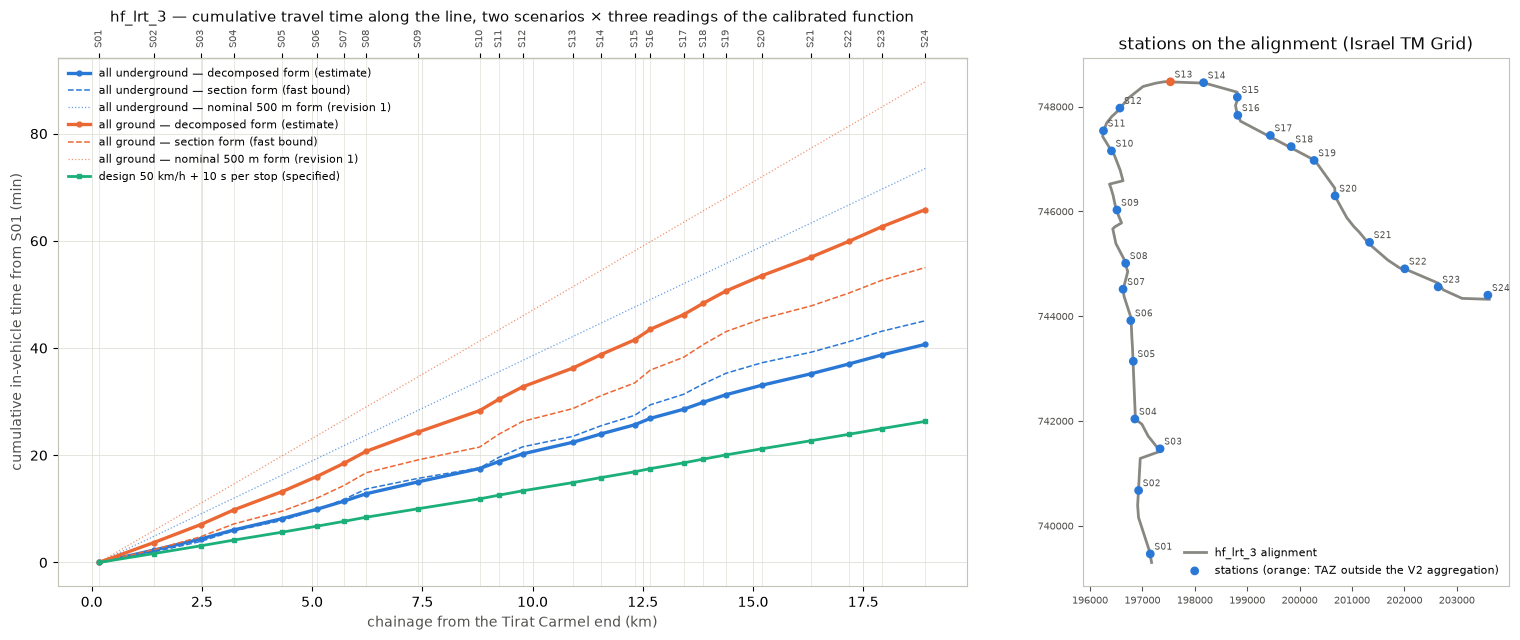

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), facecolor='white', gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
for sc, color in [('all_underground', BLUE), ('all_ground', ORANGE)]:
    ax.plot(prof['chainage_m'] / 1000, prof[f'cum_min_{sc}'], color=color, lw=2.4, marker='o', ms=3.5, label=f'{sc.replace("_", " ")} — decomposed form (estimate)')
    ax.plot(prof['chainage_m'] / 1000, prof[f'cum_min_{sc}_section_form'], color=color, lw=1.1, ls='--', label=f'{sc.replace("_", " ")} — section form (fast bound)')
    ax.plot(prof['chainage_m'] / 1000, prof[f'cum_min_{sc}_nominal500m_form'], color=color, lw=0.9, ls=':', alpha=0.7, label=f'{sc.replace("_", " ")} — nominal 500 m form (revision 1)')
ax.plot(prof['chainage_m'] / 1000, prof['cum_min_design_50kmh'], color=AQUA, lw=2.0, marker='s', ms=3, label='design 50 km/h + 10 s per stop (specified)')
for _, r in prof.iterrows(): ax.axvline(r['chainage_m'] / 1000, color=GRID, lw=0.5, zorder=0)
ax.set_xlabel('chainage from the Tirat Carmel end (km)', color=INK2); ax.set_ylabel('cumulative in-vehicle time from S01 (min)', color=INK2)
ax.set_title('hf_lrt_3 — cumulative travel time along the line, two scenarios × three readings of the calibrated function', color=INK, fontsize=11); ax.legend(frameon=False, fontsize=8)
ax.grid(True, color=GRID, lw=0.6); [s.set_color(AXIS) for s in ax.spines.values()]
sec_ax = ax.secondary_xaxis('top'); sec_ax.set_xticks(prof['chainage_m'] / 1000); sec_ax.set_xticklabels(prof['station_id'], fontsize=7, rotation=90, color=INK2)
ax = axes[1]
ax.plot(L.xy[0], L.xy[1], color=MUTED, lw=2, label='hf_lrt_3 alignment')
ax.scatter(st['x'], st['y'], c=[BLUE if pd.notna(a) else ORANGE for a in st['AggCode']], s=28, zorder=3, label='stations (orange: TAZ outside the V2 aggregation)')
for _, r in st.iterrows(): ax.annotate(r['station_id'], (r['x'], r['y']), fontsize=6.5, color=INK2, xytext=(3, 3), textcoords='offset points')
ax.set_aspect('equal'); ax.set_title('stations on the alignment (Israel TM Grid)', color=INK, fontsize=12); ax.legend(frameon=False, fontsize=8, loc='lower right'); ax.tick_params(labelsize=7, colors=INK2)
[s.set_color(AXIS) for s in ax.spines.values()]
plt.tight_layout(); fig.savefig('Output/figures/lrt_line_profile_hf_lrt_3.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## 3. Area-to-area LRT in-vehicle times (V2 trunk areas served by the line)

For the generalized-cost matrix an area pair needs one in-vehicle time. Each V2 area on the line is represented by the **station nearest its population + employment weighted centroid** (TAZ centroids weighted by 2020 residents + jobs); the area-pair IVT is the station-to-station time in the decomposed form. The line as drawn ends at Hamifrats: **Bazan-Hutsot (211), Tsomet Kiryat Ata (212) and the three branches have no station on `hf_lrt_3`**, so their LRT times cannot be produced from this geometry — they are recorded as missing in the generalized-cost inventory (step 26).

In [6]:
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID')
cent = {int(r['TAZ_NUMBER']): p.centroid for p, r in zip(polys, tz.records())}
k = xl.parse('TazAgg'); k['cx'] = [cent[t].x for t in k['TAZ']]; k['cy'] = [cent[t].y for t in k['TAZ']]
k['w'] = zon.reindex(k['TAZ'])['POPULATION'].fillna(0).values + zon.reindex(k['TAZ'])['EMPL_TOT'].fillna(0).values; k.loc[k['w'] <= 0, 'w'] = 1
ac = k.groupby('AggCode').apply(lambda g: pd.Series({'cx': np.average(g['cx'], weights=g['w']), 'cy': np.average(g['cy'], weights=g['w'])}), include_groups=False)
ac['AggAreaName'] = areas['AggAreaName']
stxy = st[['x', 'y']].values
ac['nearest_station'] = [ids[int(np.argmin(np.hypot(stxy[:, 0] - x, stxy[:, 1] - y)))] for x, y in zip(ac['cx'], ac['cy'])]
ac['dist_centroid_to_station_m'] = [np.min(np.hypot(stxy[:, 0] - x, stxy[:, 1] - y)) for x, y in zip(ac['cx'], ac['cy'])]
ac['on_line'] = ac.index.isin(st['AggCode'].dropna().astype(int))
ac.to_csv(f'{OUT}/lrt_area_representative_station.csv', float_format='%.1f')
served = [a for a in ac.index if ac.loc[a, 'on_line']]
for sc in list(SCEN) + ['design_50kmh']:
    for form, suffix in ([('decomposed', ''), ('section', '_section_form')] if sc in SCEN else [('decomposed', '')]):
        M = pd.DataFrame([[T[(sc, form)].loc[ac.loc[o, 'nearest_station'], ac.loc[d, 'nearest_station']] for d in served] for o in served], index=served, columns=served)
        M.to_csv(f'{OUT}/lrt_area_ivt_{sc}{suffix}.csv', float_format='%.2f')
print(f"areas served by a station on hf_lrt_3: {len(served)} — " + ', '.join(f'{a} {areas.loc[a, "AggAreaName"]} ({ac.loc[a, "nearest_station"]})' for a in served))
print("not served by this geometry: " + ', '.join(f'{a} {areas.loc[a, "AggAreaName"]}' for a in ac.index if not ac.loc[a, 'on_line']))
pd.read_csv(f'{OUT}/lrt_area_ivt_all_underground.csv', index_col=0).round(1)

areas served by a station on hf_lrt_3: 10 — 201 TiratCarmel (S02), 202 Matam-NeotPeres (S06), 203 HofCarmel-NeveDavid (S09), 204 Hecht-Shprintzak (S10), 205 EinHayam (S12), 206 BatGalim-KiryatEliezer (S15), 207 Hamoshava (S17), 208 LowerCity (S19), 209 Namal-Giborim (S21), 210 Hamifrats (S24)
not served by this geometry: 101 TsurShalom, 102 Kiryon, 103 KiryatBialik Center, 104 KiryatHaim, 211 Bazan-Hutsot, 212 TsometKiryatAta, 213 KiryatAta North, 214 KiryatAta North-East, 215 Shefaram, 216 Hamovil, 217 Nazareth, 301 SavyoneyYam, 302 KiryatYam A, 303 KiryatYam B+C, 304 KiryatHaim West


,201,202,203,204,205,206,207,208,209,210
201,0.0,7.6,12.7,15.2,18.0,23.4,26.3,29.0,32.9,38.4
202,7.6,0.0,5.1,7.6,10.4,15.8,18.7,21.4,25.3,30.8
203,12.7,5.1,0.0,2.5,5.2,10.6,13.5,16.3,20.2,25.6
204,15.2,7.6,2.5,0.0,2.7,8.2,11.1,13.8,17.7,23.2
205,18.0,10.4,5.2,2.7,0.0,5.4,8.3,11.0,14.9,20.4
206,23.4,15.8,10.6,8.2,5.4,0.0,2.9,5.6,9.5,15.0
207,26.3,18.7,13.5,11.1,8.3,2.9,0.0,2.7,6.6,12.1
208,29.0,21.4,16.3,13.8,11.0,5.6,2.7,0.0,3.9,9.4
209,32.9,25.3,20.2,17.7,14.9,9.5,6.6,3.9,0.0,5.5
210,38.4,30.8,25.6,23.2,20.4,15.0,12.1,9.4,5.5,0.0


## Findings

- **Geometry.** `hf_lrt_3` is one 18.94 km polyline from Hamifrats to Tirat Carmel; the 46 platform points form **24 stations** (22 platform pairs and two single points at the Hamifrats end), all within 80 m of the alignment, spanning 18.74 km between S01 (Tirat Carmel south) and S24 (Hamifrats). Mean spacing 815 m (354 m to 1,396 m). One station (S13, TAZ 1509 between Ein Hayam and Bat Galim) falls in a TAZ that the V2 aggregation does not list; it should be added to area 206 or 205 in `Corridor_TAZ_Agg_V2.xlsx`.
- **The revision-1 times were too slow, and the reason is the calibration report's 500 m assumption.** In the national GTFS the Red Line (routes 34447 / 34448, 32 stops, 21.4 km, 70.6 min scheduled) has underground sections of 970 m on average and surface sections of 577 m. The calibrated 1.961 min per underground section is therefore a 30 km/h section; read over 500 m it became 15 km/h, which is what revision 1 did. Fitted on the Red Line's 14,477 scheduled sections, the section time is 0.81 min + 1.31 min/km underground (46 km/h running, 49-second stop penalty) and 1.23 min + 1.94 min/km at the surface (31 km/h, 74 seconds), levelled to the calibration's observed means (× 0.94 underground, × 1.02 surface). On Haifa's 815 m spacing a section takes 1.77 min underground (27.6 km/h) and 2.86 min at ground level (17.1 km/h).
- **End-to-end in-vehicle time, S01 → S24 (18.74 km, 23 sections).** All underground **40.7 min** (27.6 km/h); all ground level **65.8 min** (17.1 km/h); **going underground saves 38 %**, not the 18 % of revision 1 — the two calibrated coefficients embed different section lengths, so the saving per section understates the saving per kilometre. The bounds: section form 45.1 / 55.0 min (fast for the surface, since it ignores that Haifa's surface sections are 40 % longer than the Red Line's; slightly slow underground); the revision-1 nominal 500 m form 73.5 / 89.7 min (superseded). The earlier capture-model assumption of 22–26 km/h sits inside the underground range.
- **Area coverage.** The line serves the ten trunk areas 201–210 (Tirat Carmel to Hamifrats), each represented by the station nearest its weighted centroid (S02, S06, S09, S10, S12, S15, S17, S19, S21, S24). Bazan-Hutsot (211), Tsomet Kiryat Ata (212) and the three V2 branches have no station on this geometry: their LRT skims need the branch alignments and stations to be drawn.
- **Outputs.** `Output/lrt_v2/lrt_stations_hf_lrt_3.csv` / `.geojson`, `lrt_calibration_redline_spacing_check.csv` (the Red Line sections, fit and level factors), `lrt_station_distances_km.csv`, `lrt_station_times_{all_underground,all_ground}.csv` (the decomposed-form estimate) with `…_section_form.csv` and `…_nominal500m_form.csv` as the bounds, `lrt_line_profile.csv`, `lrt_end_to_end_summary.csv`, `lrt_area_representative_station.csv`, `lrt_area_ivt_{all_underground,all_ground}.csv` (+ `_section_form`); figure `lrt_line_profile_hf_lrt_3.png`.